# 3 Data analysis

## Setup

### Load Libraries

In [29]:
library(tidyverse)
library(plotrix)
library(RColorBrewer)
library(patchwork)
library(tools)
library(readxl)
library(scales)


options(warn = -1)

### Set working directory

In [3]:
wd <- "/path/to/03_image_analysis/05_pufa_feeding"
wd <- "/Net/Groups/pbtdata/07_DD/06_PPT/05_analysis/03_image_analysis/05_pufa_feeding" #! DELETE AFTER CLEANUP
setwd(wd)

### Load and tidy metadata

In [6]:
# Load metadata Excel sheet
md_path <- file.path(wd, "02_data", "tables", "pufa_feeding_asssay_layout.xlsx")
md <- read_excel(md_path)

# Convert to tidy format
tidy_md <- md %>%
  gather(key = "column", value = "value", -plate, -row, -type) %>%
  pivot_wider(names_from = type, values_from = value) %>%
  mutate(column = as.numeric(column)) %>%
  rename(col = column) %>%
  arrange(plate, row, col) %>%
  select(-plate)


### Load and prepare raw cell data

In [9]:
# Load segmentation result table
path <- file.path(wd, "02_data", "tables", "cell_analysis.csv")
data_raw <- read.csv(path, header = TRUE, check.names = TRUE)

# Extract metadata from filenames
data <- data_raw %>%
  mutate(filename = basename(filename)) %>%
  separate(filename, into = c("row", "col", "region"), sep = "_", remove = FALSE) %>%
  select(filename, row, col, region, cell_label, area) %>%
  arrange(filename)


Warning message:
“Expected 3 pieces. Additional pieces discarded in 449339 rows [1, 2, 3, 4, 5,
6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, ...].”


## Analysis

### Summarize data by regions


In [12]:
# Calculate cell count and area summaries per region
data_summary_regions <- data %>%
  group_by(row, col, region) %>%
  summarise(
    n.region = n(),
    across(
      .cols = c(area),
      .fns = list(
        region.mean = ~mean(.x, na.rm = TRUE),
        region.max = ~max(.x, na.rm = TRUE)
      ),
      .names = "{.col}.{.fn}"
    )
  )


`summarise()` has grouped output by 'row', 'col'. You can override using the
`.groups` argument.


### Summarize data by wells

In [13]:
# Specify non-numeric or non-summary columns to exclude
exceptions <- c("filename", "row", "col", "region", "z", "cell_label")

# Identify numeric columns to summarise
columns_to_summarize <- setdiff(colnames(data_summary_regions), exceptions)

# Calculate well-level summaries (mean, standard error, max)
data_summary_wells <- data_summary_regions %>%
  group_by(row, col) %>%
  summarise(
    n = n(),
    across(
      .cols = all_of(columns_to_summarize),
      .fns = list(
        mean = ~mean(.x, na.rm = TRUE),
        se = ~sd(.x, na.rm = TRUE) / sqrt(n()),
        max = ~max(.x, na.rm = TRUE)
      ),
      .names = "{.col}.{.fn}"
    ),
    .groups = "drop"
  )


Convert column types

In [15]:
# Ensure column index is numeric
data_summary_wells <- data_summary_wells %>%
  mutate(col = as.numeric(col))


 Merge with metadata

In [16]:
# Add metadata to well-level summary
data_summary_wells_md <- merge(data_summary_wells, tidy_md, all = TRUE) %>%
  arrange(row, col)


Handle missing values


In [17]:
# Replace NA counts with 0 (e.g. for empty wells)
data_summary_wells_md <- data_summary_wells_md %>%
  replace_na(list(n = 0))

## Visualization

### Cell count heatmap
Note:
- The experiment includes a duplicate row layout without BSA to serve as a control.
- This pilot screen showed that PUFA alone was insufficient to rescue growth of the disfp– mutant.
- These additional controls are retained for transparency and context, but not emphasized. -->

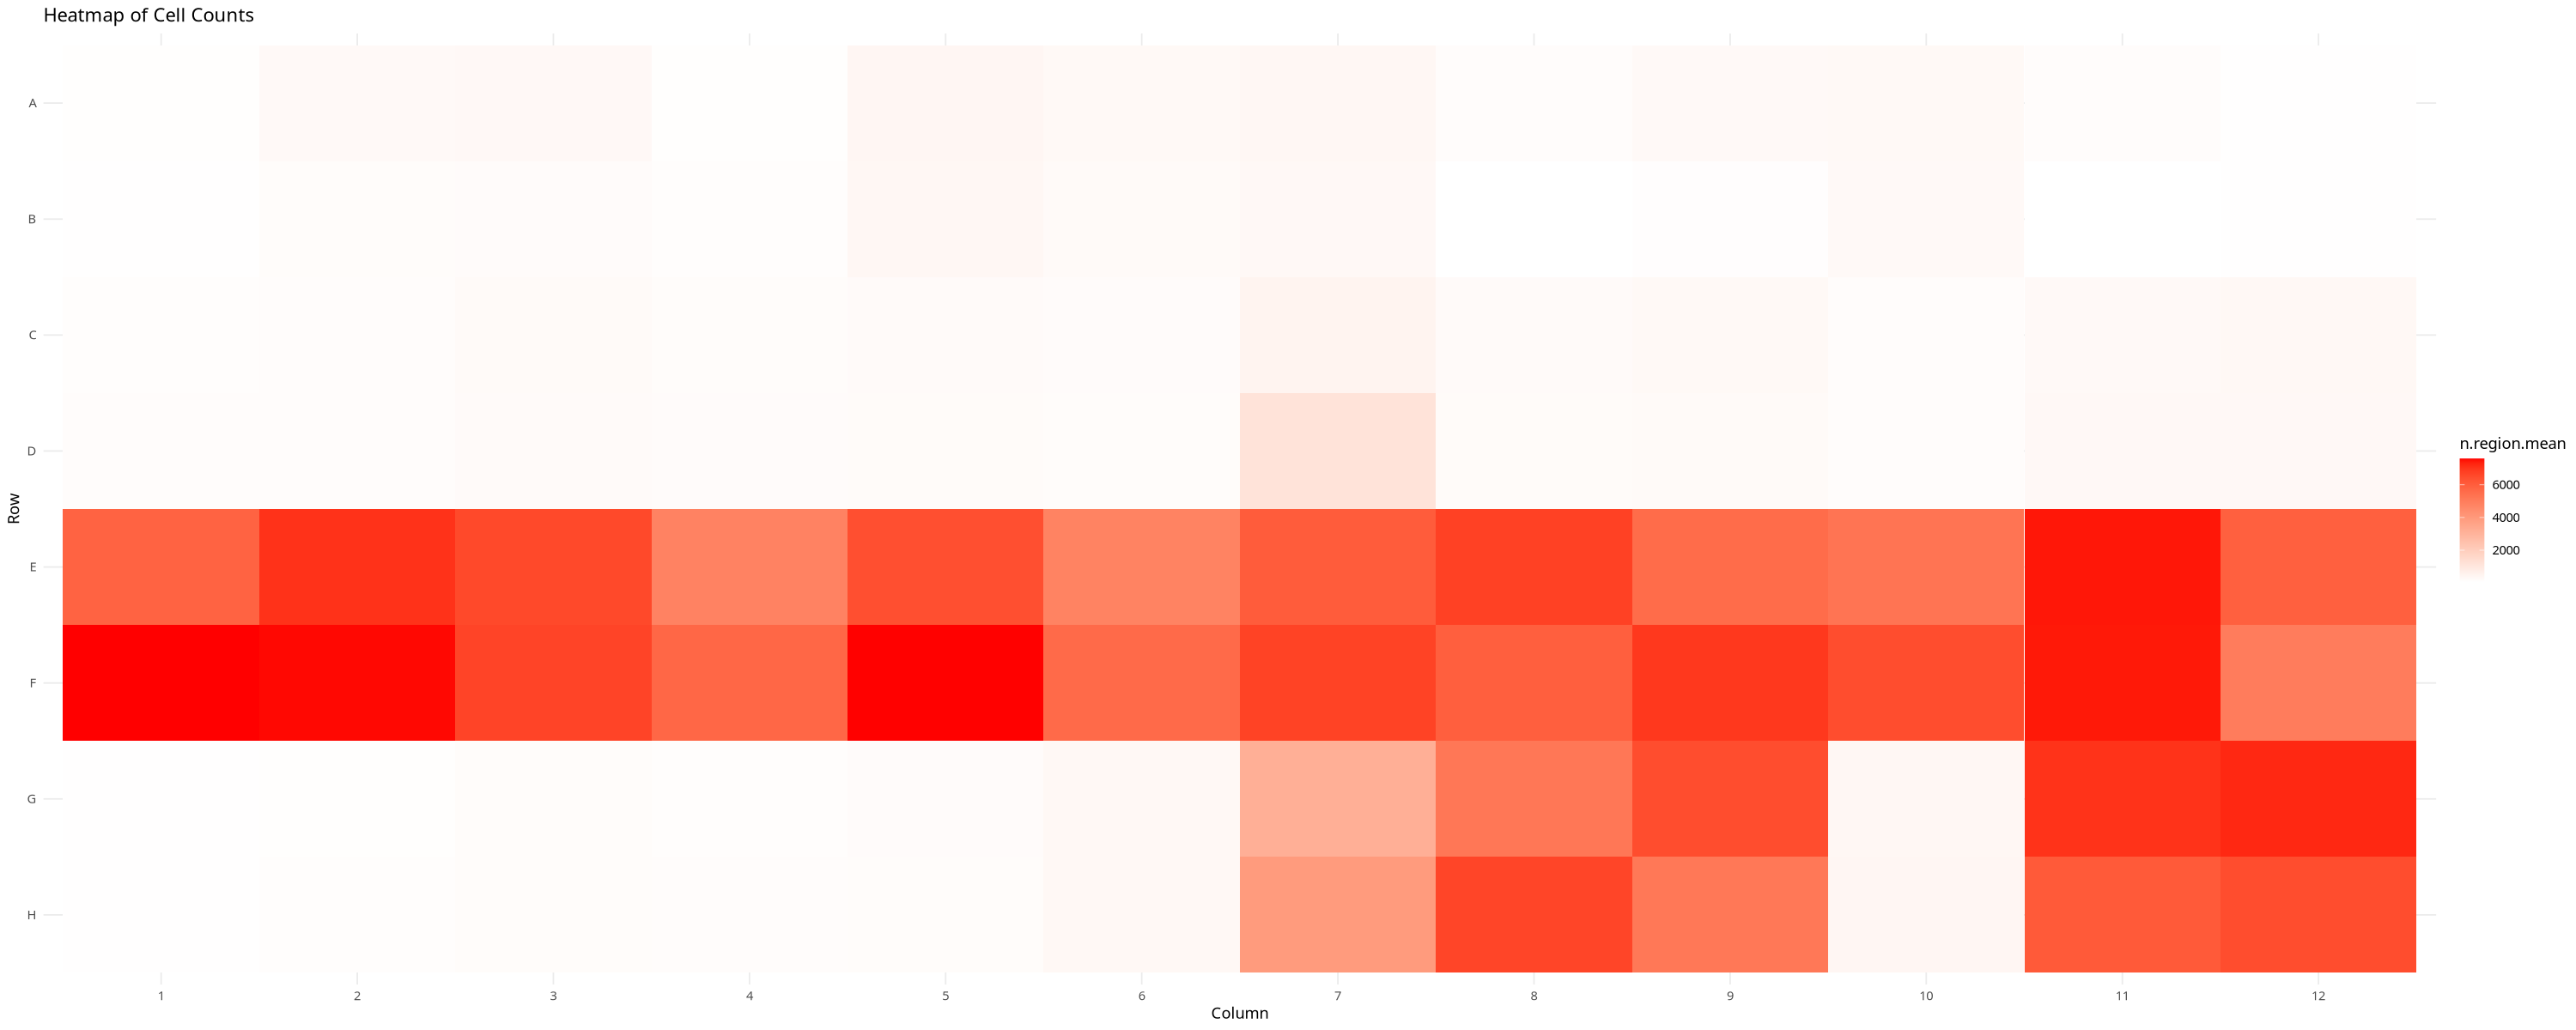

In [18]:
options(repr.plot.width = 25, repr.plot.height = 10)

data_summary_wells_md %>%
  ggplot(aes(x = factor(col), y = factor(row), fill = n.region.mean)) +
  geom_tile() +
  scale_fill_gradient(low = "white", high = "red") +
  labs(title = "Heatmap of Cell Counts", x = "Column", y = "Row") +
  scale_y_discrete(limits = rev(levels(factor(data_summary_wells_md$row)))) +
  theme_minimal()

### Bar plots
Prepare data for bar plots

In [20]:
# Rejoin metadata and filter only wells with BSA treatment
data_summary <- data_summary_regions %>%
  mutate(col = as.numeric(col)) %>%
  left_join(tidy_md) %>%
  select(row, col, region, n.region, treatment, bsa, strain, group) %>%
  filter(bsa == "bsa") %>%
  group_by(treatment, strain) %>%
  summarise(
    n = n(),
    across(
      .cols = c(n.region),
      .fns = list(
        mean = ~mean(.x, na.rm = TRUE),
        sd = ~sd(.x, na.rm = TRUE),
        max = ~max(.x, na.rm = TRUE)
      ),
      .names = "{.col}.{.fn}"
    ),
    .groups = "drop"
  )


Joining with `by = join_by(row, col)`


Define color schemes and factor levels

In [26]:
# Define strain-specific color palettes
wt_colors      <- brewer.pal(n = 9, name = "Greens")
disfp_colors   <- brewer.pal(n = 9, name = "Purples")
rescue_colors  <- brewer.pal(n = 9, name = "Blues")

color_nr <- 6

strain_colors <- c(
  "wt"    = wt_colors[color_nr],
  "disfp" = disfp_colors[color_nr]
)

strain_rename <- c(
  "disfp" = bquote(italic(disfp)^"–" ~ "mutant"),
  "wt"    = bquote("Ax2 wildtype")
)


 Define scaling parameters

In [31]:
# Image dimensions and physical scale (µm)
pixels_x <- 2049
pixels_y <- 2049
physical_length_in_uM_x <- 1339.23
physical_length_in_uM_y <- 1339.23

# Calculate scale factors
scale_factor_x <- physical_length_in_uM_x / pixels_x
scale_factor_y <- physical_length_in_uM_y / pixels_y
scale_factor   <- (scale_factor_x + scale_factor_y) / 2  # averaged

# Field of view area in mm²
FOV_area_mm2 <- (physical_length_in_uM_x * physical_length_in_uM_y) / 1e6


 Set factor levels

In [24]:
# Extract treatment levels from metadata
treatment_levels <- unlist(md[1, 2:13], use.names = FALSE)
strain_levels    <- c("wt", "disfp")

# Ensure factors are properly ordered
data_summary <- data_summary %>%
  mutate(
    treatment = factor(treatment, levels = treatment_levels),
    strain    = factor(strain, levels = strain_levels)
  )


create the figure

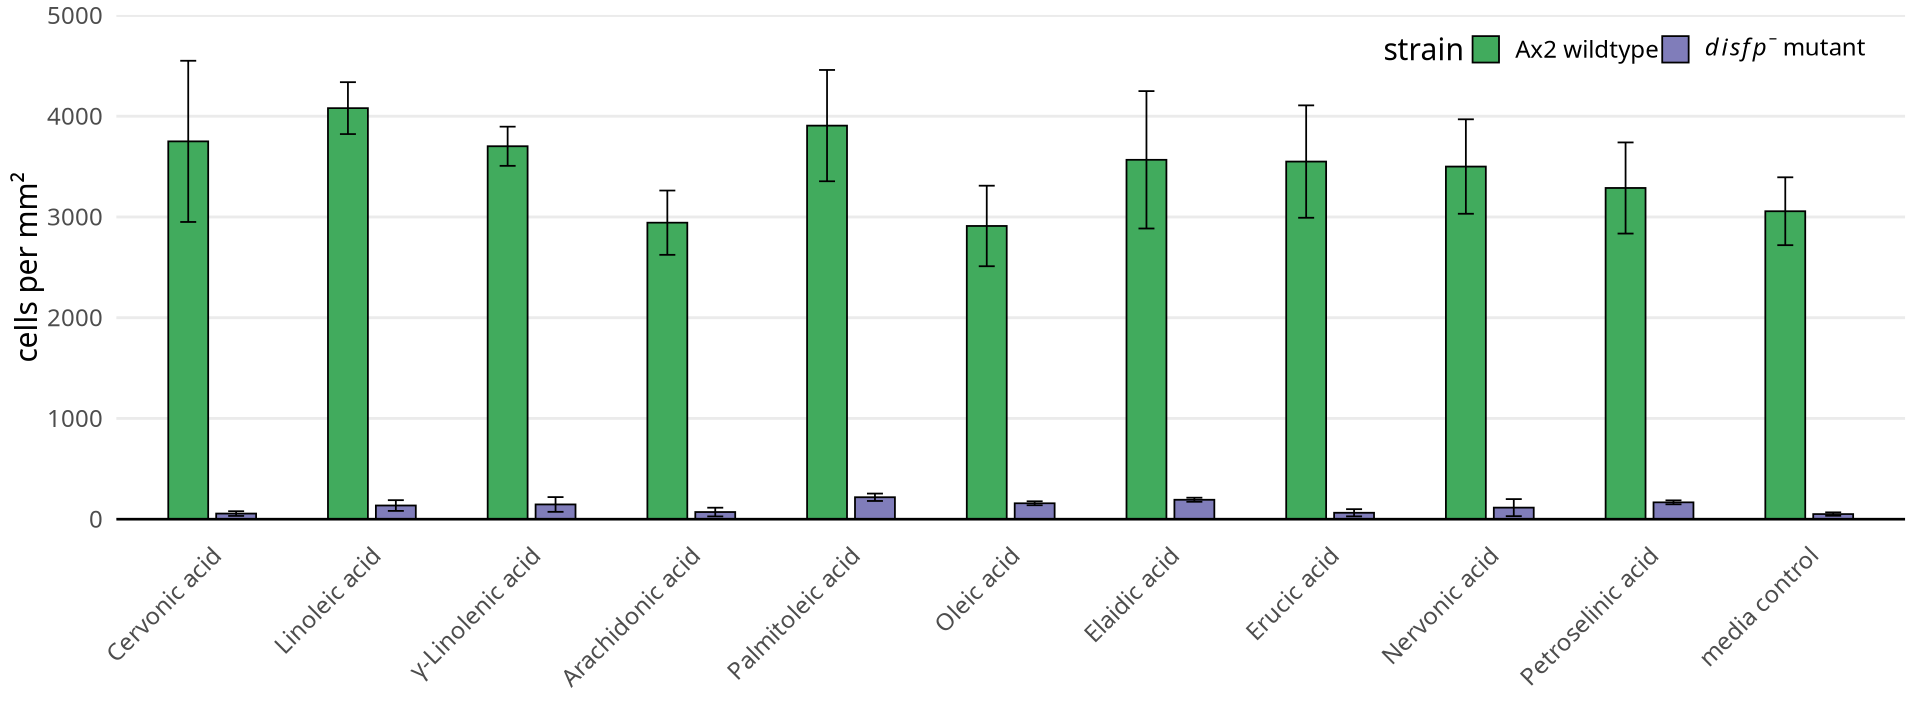

In [30]:
options(repr.plot.width = 16, repr.plot.height = 6)

data_summary %>%
  filter(treatment != "media control") %>%  # Exclude medium-only wells
  ggplot(aes(x = treatment, y = n.region.mean / FOV_area_mm2, fill = strain)) +
  geom_col(
    position = position_dodge(width = 0.6),
    width = 0.5,
    color = "black"
  ) +
  geom_errorbar(
    aes(
      ymin = (n.region.mean - n.region.sd) / FOV_area_mm2,
      ymax = (n.region.mean + n.region.sd) / FOV_area_mm2
    ),
    position = position_dodge(width = 0.6),
    width = 0.2
  ) +
  labs(y = "cells per mm²", x = "") +
  scale_fill_manual(values = strain_colors, labels = strain_rename) +
  scale_x_discrete(labels = treatment_levels) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  theme_minimal(base_size = 18) +
  guides(fill = guide_legend(direction = "horizontal")) +
  theme(
    panel.border        = element_blank(),
    panel.spacing       = unit(3, "lines"),
    panel.grid.major.x  = element_blank(),
    panel.grid.minor.x  = element_blank(),
    panel.grid.minor.y  = element_blank(),
    axis.line.x         = element_line(color = "black", size = 0.75),
    axis.ticks.x        = element_blank(),
    axis.ticks.y        = element_blank(),
    strip.text.x        = element_text(color = "black", face = "bold"),
    axis.text.x         = element_text(angle = 45, hjust = 1, vjust = 0.9),
    strip.background    = element_rect(colour = "white", fill = "white", linetype = "solid"),
    legend.position     = c(0.7, 0.99),
    legend.justification = c("left", "top")
  )
